## 지도 학습  
지도 학습은 정답은 컴퓨터에 미리 알려 주고 데이터를 학습시키는 방법이다. 지도 학습에는 Classification과 Regression이 있다. 당연히 Classification은 주어진 데이터를 정해진 범주에 따라 분류하고, Regression는 데이터들의 특성을 기준으로 연속된 값을 그래프로 표현하여 패턴이나 트렌드를 예측할 때 사용한다.  


#### K-NN  
왜 사용하나? 주어진 데이터를 Classification 할때 사용  
언제 사용하면 좋을까? K-NN은 직관적이며 사용하기 쉽기 때문에 초보자가 사용하면 좋음. 또한 훈련 데이터를 충분히 확보할 수 있는 환경에서 사용하면 좋다  
ex) 새로운 입력이 3개 있을때 해당 입력을 주변 범주에서 더 우세한 쪽으로 분류함  
예제 따라하기  
목표: 적절한 K 값에 대한 예측  
분석: 라이브러리 호출 -> 데이터셋 로딩 -> 훈련과 검증 데이터셋 분리 -> 모델 생성 -> K 값 예측

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import metrics
from sklearn.datasets import load_iris

names = ['sepal length', 'sepal width', 'petal length', 'petal width', 'class']
iris = load_iris()
X = iris.data
y = iris.target

In [2]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",50
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [4]:
from sklearn.metrics import accuracy_score
y_pred = knn.predict(X_test)
print("정확도: {:.8f}".format(accuracy_score(y_test, y_pred)))

정확도: 0.96666667


In [5]:
k = 10
acc_array = np.zeros(k)
for k in np.arange(1, k+1, 1):
    classifier = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    y_pred = classifier.predict(X_test)
    acc = metrics.accuracy_score(y_test, y_pred)
    acc_array[k-1] = acc

max_acc = np.max(acc_array)
acc_list = list(acc_array)
k = acc_list.index(max_acc)
print("정확도", max_acc, "으로 최적의 k는 =", k+1)

정확도 1.0 으로 최적의 k는 = 1


#### Supporter Vector Machine  
왜 사용하나? 주어진 데이테 대한 분류
언제 사용하면 좋을까? SVM은 커널만 적절히 선택한다면 정확도가 상당히 좋기 때문에 정확도를 요구하는 분류 문제를 다룰 때 사용하면 좋다. 또한, 텍스트를 분류할  때도 많이 사용한다

SVM은 분류를 위한 기준선을 정의하는 모델임. 즉, 분류되지 않은 새로운 데이터가 나타나면 결정 경계를 기준으로 경계의 어느 쪽에 속하는지 분류하는 모델이다.  
따라서 SVM은 Decision Boundary를 이해하는 것이 중요함. 여기서 Decision Boundary는 즉 결정 경계는 데이터를 부류하기 위한 기준선이다.  
그럼 이 결정 경계를 어디에 위치시키는게 제일 좋을까?  
결정 경계는 데이터가 분류된 클래스에서 최대한 멀리 떨어져 있을 때 성능이 가장 좋다. SVM을 이해하려면 Decision Boundary 외에도 마진이라는 개념을 이해해야  
함. 마진은 결정 경계외 SVM 사이의 거리를 의미한다.그럼 Support Vector는 무엇일까? Support Vector는 결정 경계와 가까이 있는 데이터를 의미한다. 이 데이터  
들이 경계를 정의하는 결정적인 역할을 한다고 할 수 있다. 즉, 정리하면 최적의 결정 경계는 마진을 최대로 해야한다.
이 Support Vector만 있다면 Decision Boundary를 정할 수 있기 때문에 굉장히 모델을 가볍게 만들 수 있음.  
Hard Margin => 이상치를 허용하지 않는 것
Soft Margin => 이상치들이 마진 안에 포함되는 것을 허용하는 것

In [6]:
from sklearn import svm
from sklearn import metrics
from sklearn import datasets
from sklearn import model_selection
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
# TF_CPP_MIN_LOG_LEVEL=0: 모든 로그 출력 (기본값)
# TF_CPP_MIN_LOG_LEVEL=1: INFO 메시지 출력 안함
# TF_CPP_MIN_LOG_LEVEL=2: WARNING 메시지 출력 안함
# TF_CPP_MIN_LOG_LEVEL=3: ERROR 메시지 출력 안함

iris = datasets.load_iris()
X_train, X_test, y_train, y_test = model_selection.train_test_split(iris.data, iris.target, test_size=0.6, random_state=42)

In [7]:
svm = svm.SVC(kernel='linear', C=1.0, gamma=0.5)
svm.fit(X_train, y_train)
prediction = svm.predict(X_test)
score = metrics.accuracy_score(y_test, prediction)
print("정확도: {:.8f}".format(score))

정확도: 0.98888889


위에 코드에서 보는 것 처럼 SVM은 선형 분류와 비선형 분류를 지원한다. 비선형에 대한 커널은 선형으로 분류될 수 없는 데이터들 때문에 발생했음.  
비선형 문제를 해결하는 가장 기본적인 방법은 저차원 데이터를 고차원으로 보내는 것인데, 이것은 많은 수학적 계산이 필요하기 때문에 성능에 문제를  
줄 수 있다. 이러한 문제를 해결하고자 도입한 것이 바로 커널 트릭이다. 선형 모델을 위한 kernel에는 linear kernel이 있고, 비선형 모델을 위한  
커널에는 Gaussian RBF kernel과 Polynomial kernel이 있다.  
- 선형 커널: 선형으로 분류 가능한 데이터에 적용되며 아래 수식을 사용함.  
$K(a,b)=a^Tb$  
- 다항식 커널: 실제로는 특성을 추가하지 않지만, 다항식 특성을 많이 추가한 것과 같은 결과를 얻을 수 있는 방법이다. 즉, 실제로는 특성을 추가하지 않지만,  
엄청난 수의 특성 조합이 생기는 것과 비슷한 효과를 얻기 때문에 고차원으로 데이터를 매핑이 가능하다.  
$K(a,b)=(\gamma a^T b)^d$  
$a, b$: 입력 벡터  
$\gamma$: 감마  
$d$: 차원, 이때 $\gamma$와 $d$는 하이퍼 파라미터이다  
- 가우시안 RBF 커널(Gaussian RBF kernel): 다항식 커널의 확장이라고 생각해도 좋음. 입력 벡터를 차원이 무한한 고차원으로 매핑하는 것으로, 모든 차수의 모든  
다항식을 고려한다. 즉, 다항식 커널은 차수에 한계가 있는데, 가우시안 RBF는 차수에 제한이 없이 무한하게 확장이 가능함.  
$K(a, b)=exp(-\gamma ||a-b||^2)$ 이때 역시 $\gamma$는 하이퍼 파라미터이다!

적용된 한글 폰트: Malgun Gothic


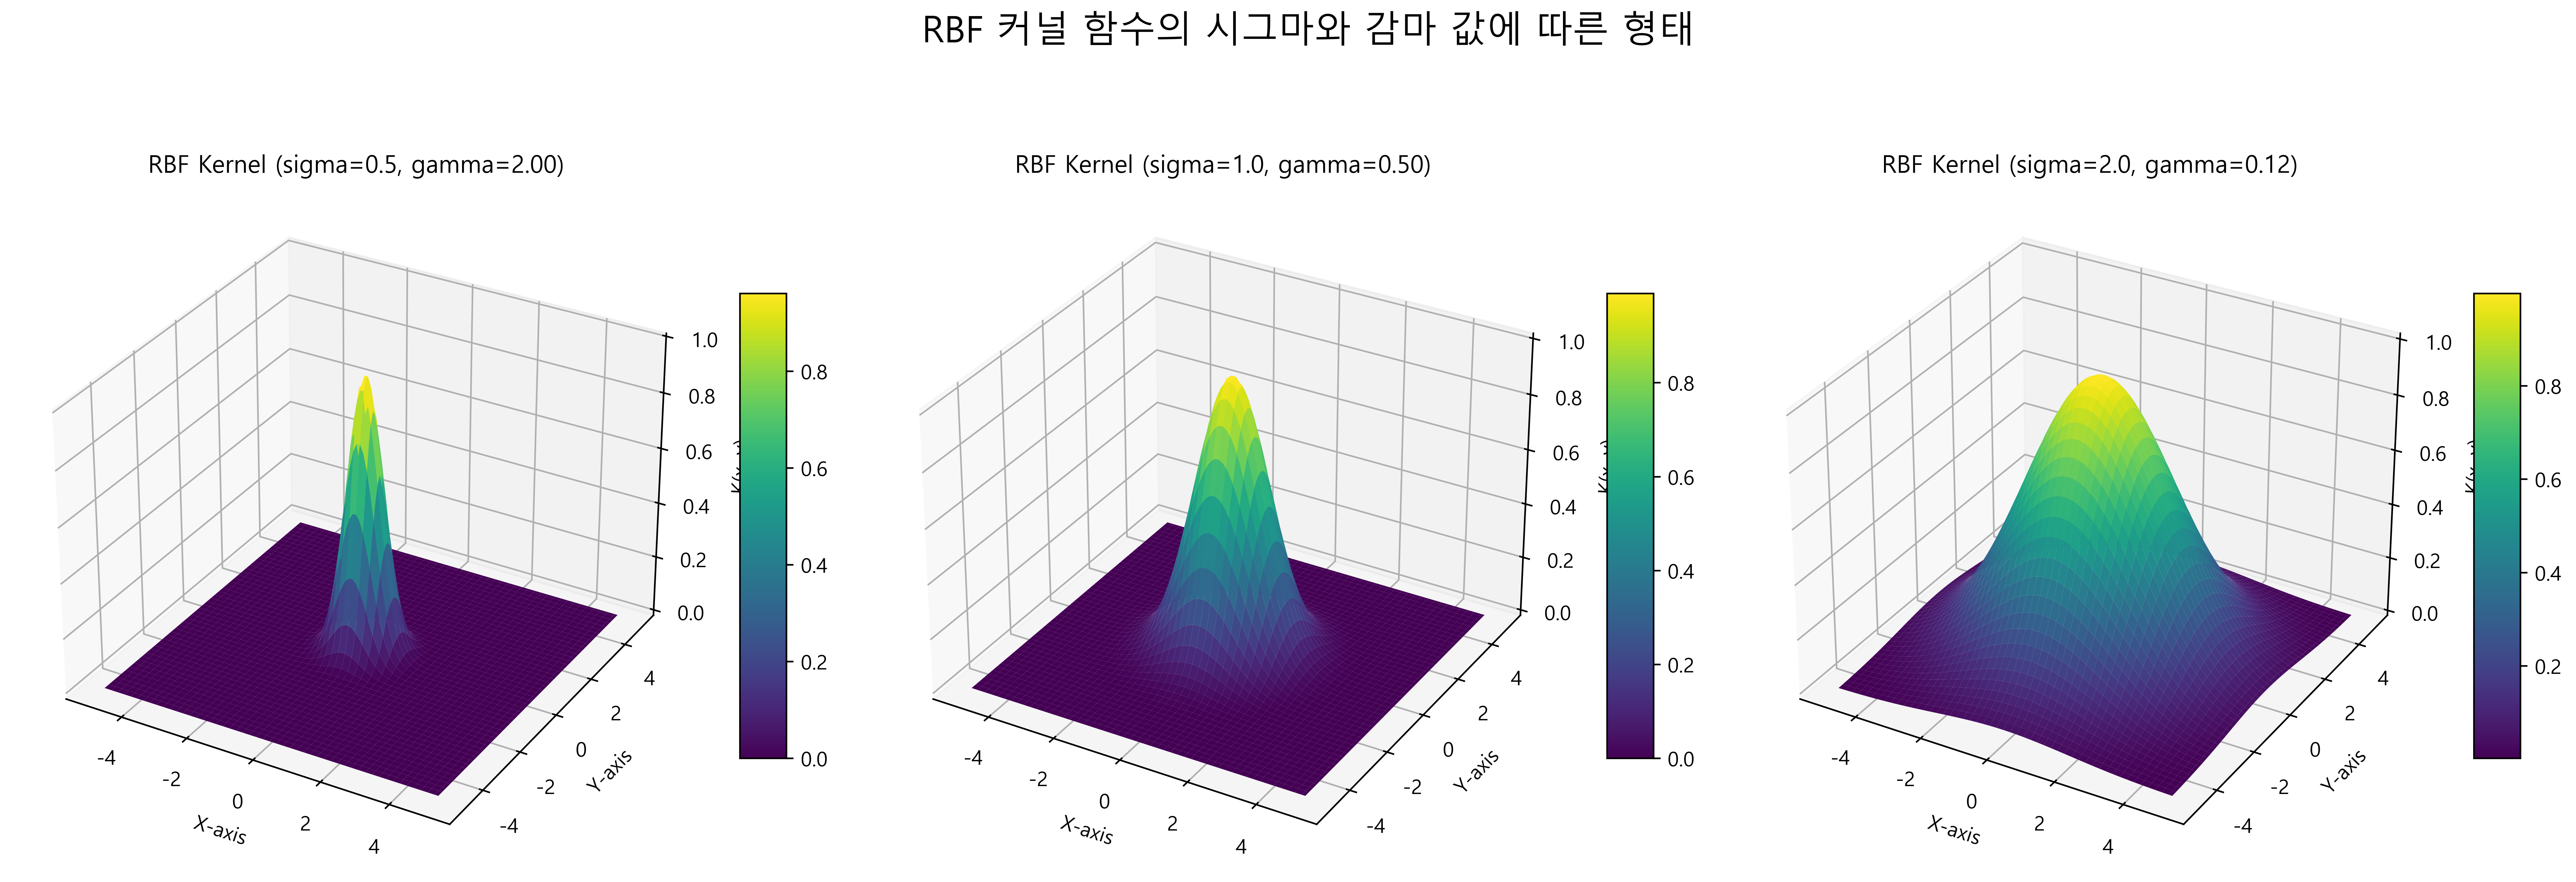

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from mpl_toolkits.mplot3d import Axes3D

# 한글 폰트 자동 설정 (Windows/macOS/Linux 공통 대응)
korean_font_candidates = [
    'Malgun Gothic',
    'AppleGothic',
    'NanumGothic',
    'Noto Sans CJK KR',
    'Noto Sans KR',
]
available_fonts = {f.name for f in fm.fontManager.ttflist}
selected_font = next((font for font in korean_font_candidates if font in available_fonts), None)

if selected_font:
    plt.rcParams['font.family'] = selected_font
    print(f'적용된 한글 폰트: {selected_font}')
else:
    print('한글 폰트를 찾지 못했습니다. Malgun Gothic 또는 NanumGothic 설치를 권장합니다.')

plt.rcParams['axes.unicode_minus'] = False

x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)

sigmas = [0.5, 1.0, 2.0]
gamma_values = [1/(2*sigma**2) for sigma in sigmas]

fig = plt.figure(figsize=(18, 6), dpi=500)
for i, sigma in enumerate(sigmas):
    Z = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='viridis', linewidth=0, antialiased=True)

    gamma = gamma_values[i]
    ax.set_title(f'RBF Kernel (sigma={sigma}, gamma={gamma:.2f})')
    ax.set_xlabel('X-axis')
    ax.set_ylabel('Y-axis')
    ax.set_zlabel('K(x, y)')

    fig.colorbar(surf, ax=ax, shrink=0.6, aspect=10)

plt.suptitle('RBF 커널 함수의 시그마와 감마 값에 따른 형태', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

쉽게 말하자면 $\sigma$가 작을수록 커널이 뾰족해지고 과적합 위험이 올라간다. 그리고 반대로 커질수록 과소적합 위험이 올라감. 그래서 적절한 값을 정하는게 좋음.

#### 결정 트리 Decision Tree  
왜 사용하는가? 주어진 데이터에 대한 Classification  
언제 사용하면 좋은가? Decision Tree는 이상치가 많은 값으로 구성된 데이터셋을 다룰 때 사용하면 좋다. 또한 결정 과정이 시각적으로 표현되기 때문에   
ML에서 어떤 방식으로 의사 결정을 하는지 알고 싶을 때 유용함.  
결정 트리는 데이터를 분류하거나 결괏값을 예측하는 분석 방법이다. 결과 모델이 트리 구조이기 때문에 결정 트리라고 한다.  
결정 트리는 데이터를 1차로 분류한 후 각 영역의 순도는 증가하고, 불순도와 불확실성은 감소하는 방향으로 학습을 진행한다.  
당연히 순도가 증가하고 불확실성은 감소하는 것은 정보 이론에서 정보 획득(information gain)이라고 하며, 순도를 계산하는 방법에는 아래 2가지를 사용함.  
- Entropy  
확률 변수의 불확실성을 수치로 나타낸 것으로, 엔트로피가 높을수록 불확실성이 높다는 의미임. 즉, 엔트로피 값이 0과 0.5라고 가정했을때, 아래와 같이 도출  
엔트로피=0=불확실성 최소 = 순도 최대  
엔트로피=0.5=불확실성 최대 = 순도 최소  
레코드 $m$개가 $A$영역에 포함되어 있다면 엔트로피는 다음 식으로 정의된다.  
$Entropy(A)=-\Sigma_{k=1}^{m}p_klog_2(p_k)$ ($P_k=A$ 영역에 속하는 데이터 가운데 k 범주에 속하는 데이터 비율)  
예를 들어 동전을 두 번 던져 앞면이 나올 확률이 1/4이고 뒷면이 나올 확률이 3/4라면 엔트로피는 아래와 같다!  
$Entropy(A)=-(\frac{1}{4})log(\frac{1}{4})-(\frac{3}{4})log(\frac{3}{4})=0.31$  
- Gini Index 지니 계수  
불순도를 측정하는 지표로, 데이터의 통계적 분산 정도를 정량화해서 표현한 값이다. 즉, 지니 계수는 원소 $n$개 중에서  
임의로 두 개를 추출했을때, 추출된 두 개가 서로 다른 그룹에 속해 있을 확률을 의미한다!!  
지니 계수는 아래와 같은 공식으로 구할 수 있으며, 지니 계수가 높을수록 데이터가 분산되어 있음을 의미함.  
$G(S)=1-\Sigma_{i=1}^{c}p_{i}^{2}$ 여기서 S는 이미 발생한 사건의 모음, c는 사건 개수  
지니 계수는 로그를 계산할 필요가 없어 엔트로피보다 계산이 빠르기 때문에 결정 트리에서 많이 사용함.  
아래에서는 유명한 ML 문제 중 하나인 타이타닉 승객의 생존 여부 예측하는 문제를 푼다!

In [9]:
import pandas as pd

df = pd.read_csv('./data/train.csv')
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [10]:
df = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Survived']]
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df = df.dropna()
X = df.drop('Survived', axis=1)
y = df['Survived']

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

In [12]:
from sklearn import tree
model = tree.DecisionTreeClassifier()

In [13]:
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [14]:
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score
print("정확도: {:.8f}".format(accuracy_score(y_test, y_pred)))

정확도: 0.81564246


In [15]:
from sklearn.metrics import confusion_matrix
pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    columns=['Predicted Not Survived', 'Predicted Survived'],
    index=['True Not Survived', 'True Survived']
)

,Predicted Not Survived,Predicted Survived
True Not Survived,97,15
True Survived,18,49


TP: 모델이 1이라고 예측했는데 실제 값도 1인 경우  
FP: 모델이 1이라고 예측했는데 실제 값은 0인 경우  
FN: 모델이 0이라고 예측했는데 실제 값은 1인 경우  
TN: 모델이 0이라고 예측했는데 실제 값도 0인 경우

#### 로지스틱 회귀와 선형 회귀  
회귀란 변수가 두개 주어졌을때, 한 변수에서 다른 변수를 예측하거나 두 변수의 관계를 규명하는데 사용하는 방법임.  
이때 사용되는 변수의 유형은 아래와 같다.  
- 독립 변수(예측 변수): 영향을 미칠 것으로 예상되는 변수  
- 종속 변수(기준 변수): 영향을 받을 것으로 예상되는 변수  
이때 두 변수 간 관계에서 독립 변수와 종속 변수의 설정은 논리적인 타당성이 있어야 함.  
예를 들어, 몸무계와 키는 둘간의 관계를 규명하는 용도로 사용됨.

#### 로지스틱 회귀  
왜 사용하나? 주어진 데이터에 대한 분류  
언제 사용하면 좋을까? 로지스틱 회귀 분석은 주어진 데이터에 대한 확신이 없거나(ex. 분류 결과에 대해 확신이 없을 때) 향후  
추가적인 훈련 데이터셋을 수집하여 모델을 훈련시킬 수 있는 환경에서 유용함.  
로지스틱 회귀는 분석하고자 하는 대상들이 두 집단 혹은 그 이상의 집단으로 나누어진 경우, 개별 관측자들이 어느 집단으로 분류  
될 수 있는지 분석하고 이를 예측하는 모형을 개발하는데 사용되는 통계기법이다. 따라서 일반적인 회귀 분석과는 차이가 있음. 

#### 최소제곱법과 최대우도법  
Mean squared와 Maximum likelihood는 랜덤 표본에서 모집단의 모수를 추정하는데 사용됨. 최소제곱법은 일반적인 회귀분석에서  
사용이 되지만, 최대우도법은 로지스틱 회귀 분석에서 사용함. 이 둘 간에 어떤 차이가 있는지 알아보자!  
- $MSE$  
$MSE=\frac{1}{n}\Sigma_{i=1}^{n}(y_i-\hat{y}_i)^2$  
- Maximum likelihood  
$\theta_{ml} = argmax_{\theta}P_{model}(Y|X;\theta)$--1  
$\theta_{ml} = argmax_{\theta}\Sigma_{i=1}^{m}logP_{model}(y_i|x_i;\theta)$--2  

1번 식의 경우 입력 값 X와 모델의 파라미터 $\theta$가 주어졌을때, Y가 나타날 확률을 최대화하는 $\theta$를 찾는 것이 최대 우도법이다.  
X와 Y가 고정된 상태에서 모델에 X를 넣었을 때 실제 값 Y에 가장 가까운 $\theta$를 찾는 것이 수식이다.  
이때 관측치 m개가 모두 서로 독립이라고 가정할 때, Underflow를 방지하고자 우도에 로그를 취한다면 최대우도 추정치 수식은 2번과 같다.

In [16]:
%matplotlib inline
from sklearn.datasets import load_digits
digits = load_digits()

print('Image data shape:', digits.data.shape)
print('Target data shape:', digits.target.shape)

Image data shape: (1797, 64)
Target data shape: (1797,)


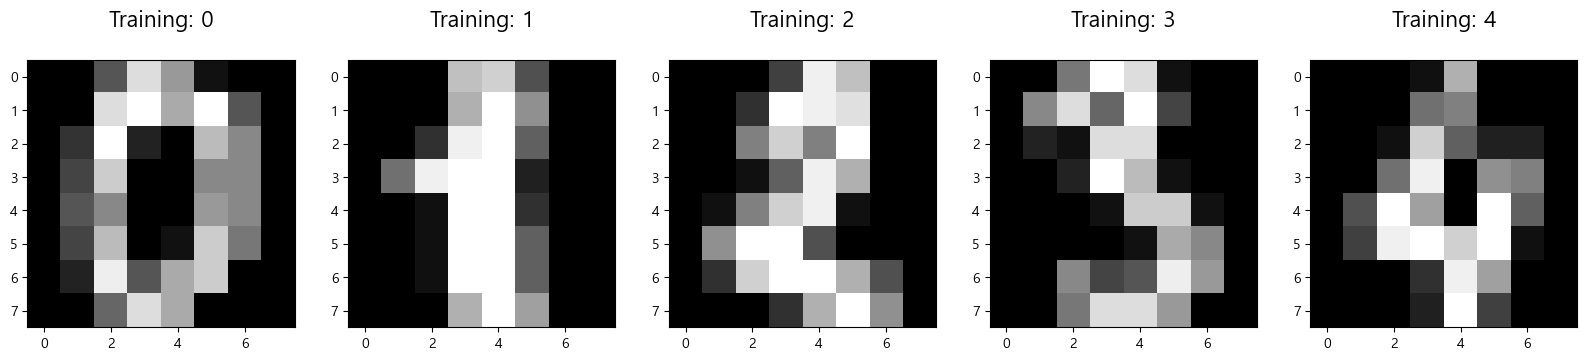

In [19]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 4))
for index, (image, label) in enumerate(zip(digits.data[0:5], digits.target[0:5])):
    plt.subplot(1, 5, index + 1)
    plt.imshow(image.reshape(8, 8), cmap=plt.cm.gray)
    plt.title('Training: %i\n' % label, fontsize=16)

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.25, random_state=42)

In [21]:
from sklearn.linear_model import LogisticRegression
logisticRegr = LogisticRegression()
logisticRegr.fit(X_train, y_train)

c:\Users\dhson\Desktop\Pytorch_Study\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [22]:
logisticRegr.predict(X_test[0].reshape(1, -1))
logisticRegr.predict(X_test[0:10])

array([6, 9, 3, 7, 2, 1, 5, 2, 5, 2])

In [23]:
predictions = logisticRegr.predict(X_test)
score = metrics.accuracy_score(y_test, predictions)
print(score)

0.9733333333333334
